# Market vs. crowd attention: LeBron to Philly

Kalshi's priced probability of LeBron signing with Philadelphia, alongside Google search interest, July 3–26, 2026.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

kalshi = pd.read_csv("../data/processed/kalshi_daily.csv", parse_dates=["date"])
trends = pd.read_csv("../data/processed/trends_daily.csv", parse_dates=["date"])

SIGN_DATE = pd.Timestamp("2026-07-24")

Matplotlib is building the font cache; this may take a moment.


## Kalshi market price

Daily close price (implied probability), with the intraday high–low range shaded.

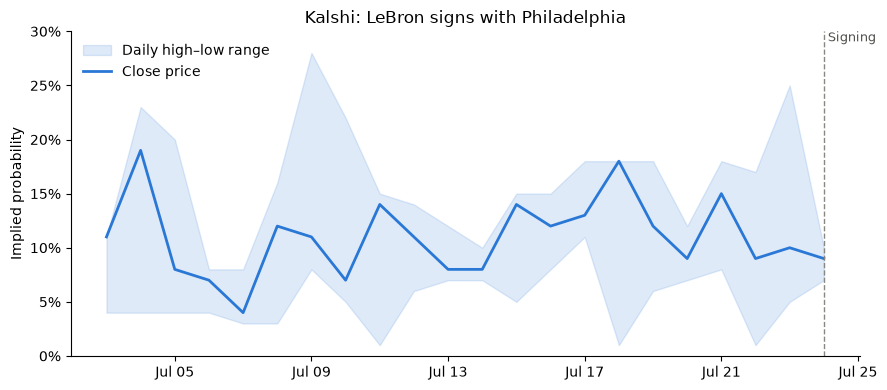

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.fill_between(kalshi["date"], kalshi["low"], kalshi["high"], color="#2a78d6", alpha=0.15, label="Daily high–low range")
ax.plot(kalshi["date"], kalshi["close"], color="#2a78d6", linewidth=2, label="Close price")

ax.axvline(SIGN_DATE, color="#898781", linestyle="--", linewidth=1)
ax.text(SIGN_DATE, 0.30, " Signing", va="top", fontsize=9, color="#52514e")

ax.set_ylim(0, 0.30)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_ylabel("Implied probability")
ax.set_title("Kalshi: LeBron signs with Philadelphia")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

## Google search interest

Relative search volume, indexed 0–100 against the single highest point across all four terms in this window — so values are only meaningful relative to that peak (July 24), not as absolute search counts.

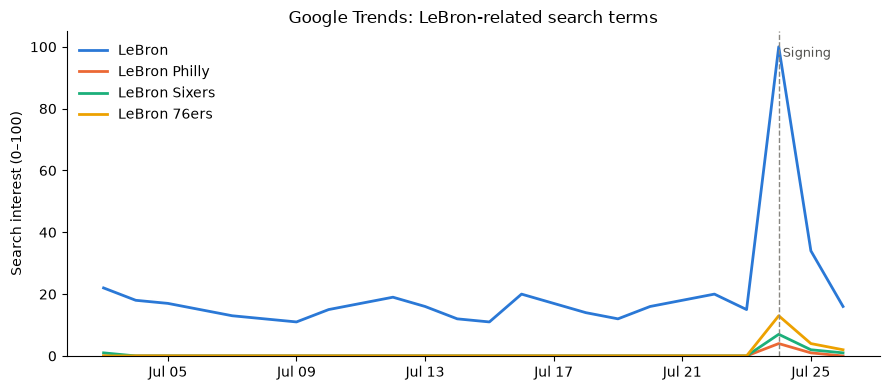

In [3]:
series = [
    ("lebron", "LeBron", "#2a78d6"),
    ("lebron_philly", "LeBron Philly", "#eb6834"),
    ("lebron_sixers", "LeBron Sixers", "#1baf7a"),
    ("lebron_76ers", "LeBron 76ers", "#eda100"),
]

fig, ax = plt.subplots(figsize=(9, 4))

for col, label, color in series:
    ax.plot(trends["date"], trends[col], color=color, linewidth=2, label=label)

ax.axvline(SIGN_DATE, color="#898781", linestyle="--", linewidth=1)
ax.text(SIGN_DATE, 100, " Signing", va="top", fontsize=9, color="#52514e")

ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_ylabel("Search interest (0–100)")
ax.set_title("Google Trends: LeBron-related search terms")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()